In [3]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

random_state = 42
np.random.seed(random_state)
# Variables
file_name= 'exam_data.csv'
df=pd.read_csv(file_name)
df.head()

,A0,A1,A2,y
0,2067.582042,-15.259519,0.020472,2
1,1319.589579,-18.412320,0.521308,0
2,1170.212183,-19.470602,0.814986,0
3,1424.162191,9.867841,0.848751,1
4,1551.069098,11.809364,0.884964,1


### Separate X and y and pairplot X, then comment results

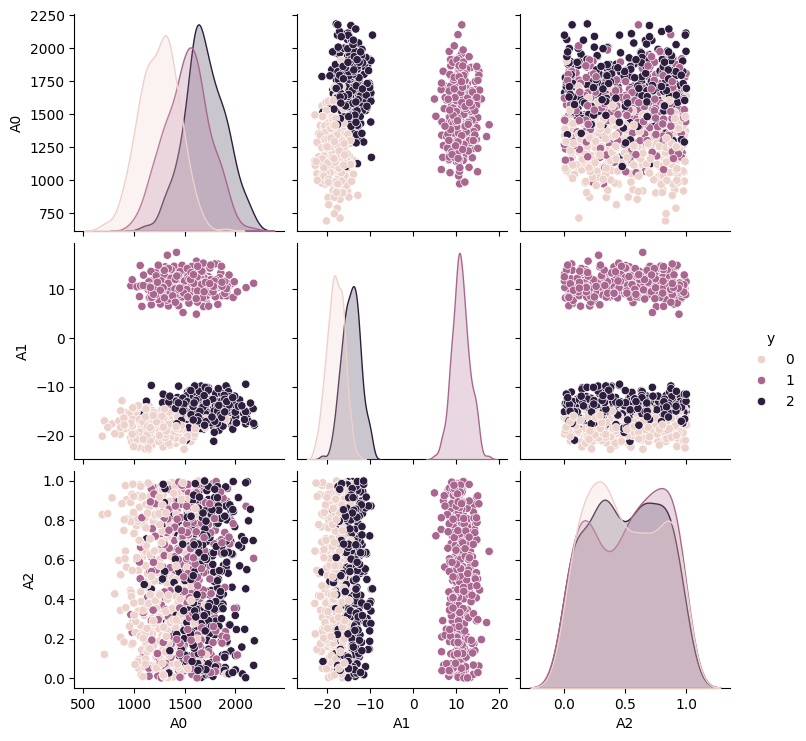

In [9]:
X=df.drop('y', axis=1)
y=df['y']
sns.pairplot(df, hue='y')


### Find the best clustering scheme for X then plot the silhouhette for an appropriate range of parameters and show the chosen hyperparameters

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Range of possible clusters
k_range = range(2,11)

# Distortion, Silhouette Score and size deviation as measures
distortions = []
silhouette_scores = []
size_deviation = []

for i in k_range:

    # Iterate over our range of possible clusters
    km = KMeans(n_clusters = i,
                init = 'k-means++',
                n_init = 10,
                max_iter = 300,
                random_state = random_state)

    # Fit predict
    y_km = km.fit_predict(X)

    # Compute the deviation with the provided formula
    deviation = np.sqrt(np.unique(y_km, return_counts = True)[1].var())/i

    # Store the data in the arrays
    distortions.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X,y_km))
    size_deviation.append(deviation)



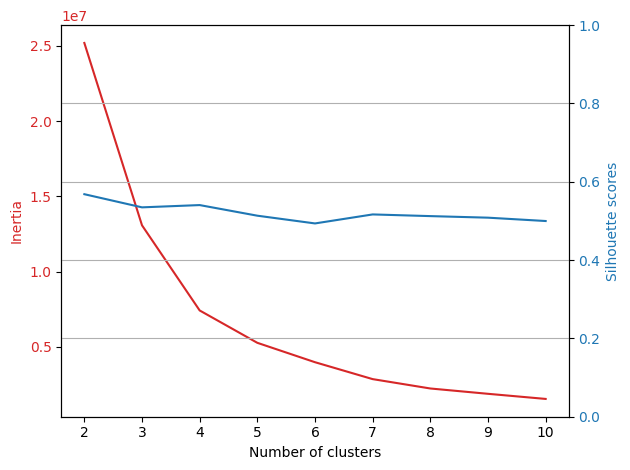

In [16]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(k_range, distortions, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Silhouette scores', color=color)  # we already handled the x-label with ax1
ax2.plot(k_range, silhouette_scores, color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0,1) # the axis for silhouette is [0,1]
plt.grid()
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

### Decide the number of clusters to use

2 clusters is the right choice, it' s also evident by looking at the pairplot figures, with this much inertia we could have distortion but it's not required to considered it by text, 4 clusters gives better prediction results

### Fit the clustering scheme, store cluster labels in y_km and output silhouette score

In [33]:
km = KMeans(n_clusters = 4, init = 'k-means++', n_init = 10, max_iter = 300, random_state = random_state)

# Fit and predict
y_km = km.fit_predict(X)
silhouette_score(X,y_km)

0.5405223516788928

### Labels in last columns 'y' as GOLD STANDARD, quantify the matching

In [34]:
from sklearn.metrics.cluster import pair_confusion_matrix
pcm = pair_confusion_matrix(y,y_km)
pcm
rights=pcm[0][0]+pcm[1][1]
totalpred= pcm[0][0]+pcm[1][1]+pcm[0][1]+pcm[1][0]
print(f"with 2 clusters we have a success rate in prediction of: {rights/totalpred * 100}%")

with 2 clusters we have a success rate in prediction of: 64.60220220220219%
